# To do
- Make bin size smaller (currently 100 ms, try 50 ms)
- CI instead of SEM
- Check usage of labels vs probabilities for predictions accuracy
- Remove misses from analysis! (done in within decoder and epoch cross decoder)
- Use only single units vs MUA
- Cortical neurons (depth < 1.5 mm) vs deep neurons (depth > 1.5 mm)

From meeting with Jaime:
Alexis, remember to make a summary bullet lists from yesterday’s meeting. I think it was quite productive and I feel we have a more clear idea of what to do.
I was thinking a bit more about decoding the stimulus or the choice. Perhaps one way to make it simpler is to:
- Train with ALL engaged trials (correct and error) on
    - predicting the stimulus in stim epoch (Stim Code)
    - predicting the choice in Delay epoch (Delay Code)
    - predicting the choice in licking epoch (Response Code).
I think by combining correct and error trials in the training, it is possible that the Stim Code is not as contaminated by persistent neurons as when you only use correct trials (because in correct trials Stim and choice always match!).
- If you train with all engaged trials using k-fold, you can later compute the decoding accuracy separately for correct and error (engaged) trials by simply separating them in the testing set.

- From Inagaki et al 2022 (MEthods ‘Coding Direction Analusys’), we should take the computation of the Ramp Mode (they call it D_ramp) and the Go Mode (D_Go). In the methods they describe how to compute them. They do not train decoders but simply compute the population vector difference between two average conditions. That gives you a direction vector in the n-space D_X where you can project the activity of the population at any time point of any trial. They kind of cross-validate by computing the direction vector with some trials (training) and projecting some others (testing). But you could apply the same idea of D_ramp and D_Go using the decoders approach:
    - For D_ramp you have to train a decoder to distinguish from population activity two categories: pre-stim vs delay. Each trial contributes therefore with two samples (pre-stim and delay; unlike when training for choice or stim where each trial is always one sample). We will need to think the consequences of this within-trial link between pairs of samples when doing CV.
    - Once you train your pre-stim VS delay decoder, you don’t want to plot the trace of the accuracy because it can be high both in pre-stim and delay epochs, but the prob(decoder says ‘delay’). This prob should go from values under 0.5 in pre-stim epoch to above 0.5 in the delay epoch. Makes sense?

There are some qualitative differences with what you may be finding:
- They see a very clear difference between the Delay code in Right vs Left trials and which corresponds to Contra and Ipsi, resp (they aways record in the Left hemisphere). You could check this by computing the decoder accuracy separately for contra vs ipsi trials (because you do have recordings from the two hemispheres, right?)
- They also see this prestimulus decoding of the stimulus in error trials. It is not clear to me yet, whether this is artifact del slow drift of the neural activity or it is physiological (i.e. there is an imbalance in the activity of choice neurons before the stimulus that generates the error) but it is something which would be worth looking in detail.
- Finally, the see that in miss trials, there are not Lick decoding (obvious), the Delay ramp is lower and the Go mode is there but also kind of lower. They probably have very few miss trials and things look noisy, but still, they have already done quite a bit in this regard.

Jaime, I agree that yesterday was a very productive meeting. This is what I have in my notes, please add anything I might have forgotten:
- Clean neurons that dissappear
    - FR < 1 spike/s --> Remove
    - Use valid trials to compute for every neuron:  var(FR) / mean(FR) per trial. Plot distribution and play with threshold to remove outliers at the tails
- Re-read Ashwood 2022, check where they compare the RTs across states if there're differences
- Check code overlap in Tiffany's paper (significance expected between stimulus and delay but not between delay and response)
- Small bump in response code of epoch decoder could be anticipatory licks (to the air) or motor getting stuck in some trials
    - Test hypothesis by removing aberrant licks (licks that happen before response window opens) or by removing those trials and checking if the small bump dissappear
- Repeat analyses but predicitng choice instead of stimulus side (that should make the downward in error trials become mirrored but positive)
- Study Inagaki's and Svoboda's works because they're becoming even more relevant:
    - Thalamus-driven functional populations in frontal cortex support decision-making
    - A midbrain-thalamus-cortex circuit reorganizes cortical dynamics to initiate movement

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ephys.decoder import *
# plt.style.use('default')  # Resets to standard white background
# sns.set_theme()
# sns.set_style('ticks')
# sns.set_context('talk')
# sns.set_context('poster')
from my_fun.my_fun import fig_size, save_notebook_files
from glue_sessions.glue_sessions import glue_groups

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

'.npy' files exist in folder. Proceeding...
Processing session 1/4: 000_2024-07-08_14-58-57
                                 Session   Side  Total  Correct  Error  \
0  000_stage_training_v5_20240708-151437   Left    176       39    116   
1  000_stage_training_v5_20240708-151437  Right    163      134     14   

   HitRate  ErrorRate  
0     0.22       0.66  
1     0.82       0.09  
'.npy' files exist in folder. Proceeding...
Processing session 2/4: 000_2024-07-10_14-32-41
                                 Session   Side  Total  Correct  Error  \
0  000_stage_training_v5_20240710-144733   Left    157       79     47   
1  000_stage_training_v5_20240710-144733  Right    150       71     52   

   HitRate  ErrorRate  
0     0.50       0.30  
1     0.47       0.35  
There are no spike count files in the folder. Skipping...
'.npy

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

In [3]:
# Plotting style
sns.set_theme(style='ticks', context='notebook')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'svg'
# %config InlineBackend.figure_format = 'retina'

# Load data

In [4]:
# df = glue_groups(experiments=['2AFC_5', 'Ephys'])
# df = df.dropna(subset=['Subject'])
# df.Subject = df.Subject.astype(int).astype(str).str.zfill(3)

In [4]:
subjects = ['000', '007', '009']  # Removed 001 (all sessions bad)
folder_parent = Path.home() / 'data'

In [6]:
# error_sessions = {s: preprocess_subject(s) for s in subjects}
#
# ephys_ids = {}
# for subject in subjects:
#     ephys_ids[subject] = get_ephys_sessions(subject)
#     ephys_ids[subject] = [id for id in ephys_ids[subject] if id not in error_sessions[subject]]
#
# behavior = {}
# for subject in subjects:
#     folder_parent = Path.home() / 'data' / subject
#     behavior[subject] = []
#     for i in ephys_ids[subject]:
#         path_behavior = get_behavior_id(i)
#         filename = path_behavior.name
#         folder_child = folder_parent / i
#         df = pd.read_csv(folder_child / filename)
#         behavior[subject].append(df)
#
# folder_parent = Path.home() / 'data'

Bad sessions:

- 007
    - '007_2024-07-06_11-16-25'
    - '007_2024-07-07_13-20-29'
    - '007_2024-07-12_13-29-26'. # ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 1. Extreme right bias

In [5]:
compute = False  # Flag to recompute decoders or load saved results

# Within temporal decoder

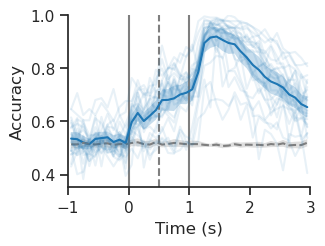

In [108]:
figsize = fig_size(n_cols=2)

keys = ['acc', 'acc_null', 'pred', 'pred_err']
mean_results = {k: [] for k in keys}

for subj in subjects:

    if compute:  # Run mean within decoder across sessions
        results = mean_decoder(subj, what='stim', kind='within', hit_only=True, engagement=1, save=True)
    else:  # Load mean within decoder results across sessions
        filename = 'stim_within_decoder_hit_only_engaged.pkl'  # Hit only, engaged
        path = Path(folder_parent / subj / filename)
        with open(path, 'rb') as f:
            results = pickle.load(f)

    for k in keys:
        mean_results[k].extend(results.get(k, []))
        mean_results['bins'] = results['bins']

    # # Plot mean within decoder results across sessions for each subject
    # plt.figure(constrained_layout=True, figsize=figsize)
    # plot_mean_within_decoder(results, z_null=False)
    # n_sessions = len(results['acc'])
    # n_trials = np.sum([results['acc'][i].shape[0] for i in range(len(results['acc']))])
    # plt.title(f'Decoding accuracy\n'
    #           f'{subj}, {n_sessions} sessions, {n_trials} trials')

# Plot mean within decoder results across mice
plt.figure(constrained_layout=True, figsize=figsize)
plot_mean_within_decoder(mean_results, z_null=False)
n_sessions = len(mean_results['acc'])
n_trials = np.sum([mean_results['acc'][i].shape[0] for i in range(len(mean_results['acc']))])
# plt.title(f'Decoding accuracy\n'
#           f'{len(subjects)} mice, {n_sessions} sessions, {n_trials} trials')

# Cross temporal decoder

## Aligned to stimulus onset

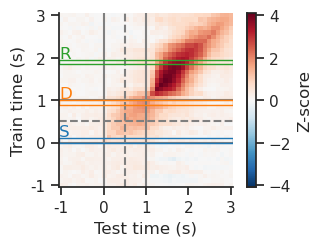

In [104]:
figsize = fig_size(n_cols=2)

keys = ['acc', 'acc_null', 'pred', 'pred_err']
mean_results = {k: [] for k in keys}

for subj in subjects:

    if compute:  # Run mean cross decoder across sessions
        results = mean_decoder(kind='cross', save=True)
    else:  # Load mean within decoder results across sessions
        filename = 'stim_cross_hit_only_engaged.pkl'
        # filename = 'stim_cross_hit_only_engaged_(resp aligned).pkl'
        path = Path(folder_parent / subj / filename)
        with open(path, 'rb') as f:
            results = pickle.load(f)

    for k in keys:
        mean_results[k].extend(results.get(k, []))
        mean_results['bins'] = results['bins']

    # # Plot mean cross decoder results across sessions for each subject
    # plt.figure(constrained_layout=True, figsize=figsize)
    # plot_mean_cross_decoder(results, z_null=True)
    # n_sessions = len(results['acc'])
    # n_trials = np.sum([results['acc'][i].shape[0] for i in range(len(results['acc']))])
    # plt.title(f'Decoding accuracy\n'
    #           f'{subj}, {n_sessions} sessions, {n_trials} trials')

# Plot mean within decoder results across mice
plt.figure(constrained_layout=True, figsize=figsize)
plot_mean_cross_decoder(mean_results, align='stim', z_null=True)
n_sessions = len(mean_results['acc'])
n_trials = np.sum([mean_results['acc'][i].shape[0] for i in range(len(mean_results['acc']))])
# plt.title(f'Decoding accuracy\n'
#           f'{len(subjects)} mice, {n_sessions} sessions, {n_trials} trials')

## Aligned to first lick

In [9]:
figsize = fig_size(n_cols=2)

keys = ['acc', 'acc_null', 'pred', 'pred_err']
mean_results = {k: [] for k in keys}

for subj in subjects:

    if compute:  # Run mean cross decoder across sessions
        results = mean_decoder(kind='cross', save=True)
    else:  # Load mean within decoder results across sessions
        # filename = 'stim_cross_hit_only_engaged.pkl'
        # filename = 'stim_cross_hit_only_engaged_(resp aligned).pkl'
        path = Path(folder_parent / subj / filename)
        with open(path, 'rb') as f:
            results = pickle.load(f)

    for k in keys:
        mean_results[k].extend(results.get(k, []))
        mean_results['bins'] = results['bins']

    # # Plot mean cross decoder results across sessions for each subject
    # plt.figure(constrained_layout=True, figsize=figsize)
    # plot_mean_cross_decoder(results, z_null=True)
    # n_sessions = len(results['acc'])
    # n_trials = np.sum([results['acc'][i].shape[0] for i in range(len(results['acc']))])
    # plt.title(f'Decoding accuracy\n'
    #           f'{subj}, {n_sessions} sessions, {n_trials} trials')

# Plot mean within decoder results across mice
plt.figure(constrained_layout=True, figsize=figsize)
plot_mean_cross_decoder(mean_results, align='resp', z_null=True)
n_sessions = len(mean_results['acc'])
n_trials = np.sum([mean_results['acc'][i].shape[0] for i in range(len(mean_results['acc']))])
# plt.title(f'Decoding accuracy\n'
#           f'{len(subjects)} mice, {n_sessions} sessions, {n_trials} trials')

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (25,) + inhomogeneous part.

<Figure size 313.5x235.125 with 0 Axes>

# Epoch cross temporal decoder
Aligned to stimulus onset

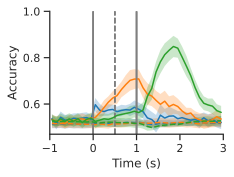

In [76]:
figsize = fig_size(n_cols=2)

keys = ['acc', 'acc_null', 'pred', 'pred_err']

mean_results_stim = {k: [] for k in keys}
mean_results_delay = {k: [] for k in keys}
mean_results_resp = {k: [] for k in keys}

for subj in subjects:

    if compute:  # Run mean epoch cross decoder across sessions
        results_stim = mean_decoder(subject=subj, what='stim', kind='epoch', epoch='stim', save=True)
        results_delay = mean_decoder(subject=subj, what='stim', kind='epoch', epoch='delay', save=True)
        results_resp = mean_decoder(subject=subj, what='stim', kind='epoch', epoch='resp', save=True)
    else:  # Load mean epoch cross decoder results across sessions
        filename_stim = 'stim_epoch_decoder_stim_hit_only_engaged.pkl'
        filename_delay = 'stim_epoch_decoder_delay_hit_only_engaged.pkl'
        filename_resp = 'stim_epoch_decoder_resp_hit_only_engaged.pkl'
        with open(Path(folder_parent / subj / filename_stim), 'rb') as f:
            results_stim = pickle.load(f)
        with open(Path(folder_parent / subj / filename_delay), 'rb') as f:
            results_delay = pickle.load(f)
        with open(Path(folder_parent / subj / filename_resp), 'rb') as f:
            results_resp = pickle.load(f)

    for k in keys:
        mean_results_stim[k].extend(results_stim.get(k, []))
        mean_results_stim['bins'] = results_stim['bins']
        mean_results_delay[k].extend(results_delay.get(k, []))
        mean_results_delay['bins'] = results_delay['bins']
        mean_results_resp[k].extend(results_resp.get(k, []))
        mean_results_resp['bins'] = results_resp['bins']

    # # Plot mean epoch cross decoder results across sessions
    # plt.figure(constrained_layout=True, figsize=figsize)
    # plot_mean_epoch_cross_decoder(results_stim, epoch='stim', errorbar='ci', z_null=False)
    # plot_mean_epoch_cross_decoder(results_delay, epoch='delay', errorbar='ci', z_null=False)
    # plot_mean_epoch_cross_decoder(results_resp, epoch='resp', errorbar='ci', z_null=False)
    # n_sessions = len(results_stim['acc'])
    # n_trials = np.sum([results_stim['acc'][i].shape[0] for i in range(len(results_stim['acc']))])
    # plt.title(f'Decoding accuracy\n'
    #           f'{subj}, {n_sessions} sessions, {n_trials} trials')

# Plot mean within decoder results across mice
plt.figure(constrained_layout=True, figsize=figsize)
plot_mean_epoch_cross_decoder(mean_results_stim, epoch='stim', errorbar='ci', z_null=True)
plot_mean_epoch_cross_decoder(mean_results_delay, epoch='delay', errorbar='ci', z_null=True)
plot_mean_epoch_cross_decoder(mean_results_resp, epoch='resp', errorbar='ci', z_null=True)
n_sessions = len(mean_results['acc'])
n_trials = np.sum([mean_results['acc'][i].shape[0] for i in range(len(mean_results['acc']))])
# plt.title(f'Decoding accuracy\n'
#           f'{len(subjects)} mice, {n_sessions} sessions, {n_trials} trials')
plt.gca().get_legend().remove()

## Licks
Aligned to first lick

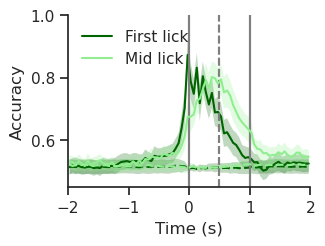

In [39]:
figsize = fig_size(n_cols=2)

keys = ['acc', 'acc_null', 'pred', 'pred_err']

mean_results_first_lick = {k: [] for k in keys}
mean_results_mid_lick = {k: [] for k in keys}

for subj in subjects:

    if compute:  # Run mean epoch cross decoder across sessions
        results_first_lick = mean_decoder(subj, what='stim', align='resp', kind='epoch', epoch='first_lick', epoch_ortho=None, split_by=None, drop_miss=True, hit_only=True, engagement=1, n_shuffles=100, plot=False, save=True)
        results_mid_lick = mean_decoder(subj, what='stim', align='resp', kind='epoch', epoch='mid_lick', epoch_ortho=None, split_by=None, drop_miss=True, hit_only=True, engagement=1, n_shuffles=100, plot=False, save=True)

    else:  # Load mean epoch cross decoder results across sessions
        filename_first_lick = 'stim_epoch_decoder_first_lick_hit_only_engaged_(resp aligned).pkl'
        filename_mid_lick = 'stim_epoch_decoder_mid_lick_hit_only_engaged_(resp aligned).pkl'

        with open(Path(folder_parent / subj / filename_first_lick), 'rb') as f:
            results_first_lick = pickle.load(f)
        with open(Path(folder_parent / subj / filename_mid_lick), 'rb') as f:
            results_mid_lick = pickle.load(f)

    for k in keys:
        mean_results_first_lick[k].extend(results_first_lick.get(k, []))
        mean_results_first_lick['bins'] = results_first_lick['bins']
        mean_results_mid_lick[k].extend(results_mid_lick.get(k, []))
        mean_results_mid_lick['bins'] = results_mid_lick['bins']

    # # Plot mean epoch cross decoder results across sessions
    # plt.figure(constrained_layout=True, figsize=figsize)
    # plot_mean_epoch_cross_decoder(results_stim, epoch='stim', errorbar='ci', z_null=False)
    # n_sessions = len(results_stim['acc'])
    # n_trials = np.sum([results_stim['acc'][i].shape[0] for i in range(len(results_stim['acc']))])
    # plt.title(f'Decoding accuracy\n'
    #           f'{subj}, {n_sessions} sessions, {n_trials} trials')

# Plot mean within decoder results across mice
plt.figure(constrained_layout=True, figsize=figsize)
plot_mean_epoch_cross_decoder(mean_results_first_lick, epoch='first_lick', errorbar='ci', z_null=False)
plot_mean_epoch_cross_decoder(mean_results_mid_lick, epoch='mid_lick', errorbar='ci', z_null=False)
n_sessions = len(mean_results_first_lick['acc'])
n_trials = np.sum([mean_results_first_lick['acc'][i].shape[0] for i in range(len(mean_results_first_lick['acc']))])
# plt.title(f'Decoding accuracy\n'
#           f'{len(subjects)} mice, {n_sessions} sessions, {n_trials} trials')

To do:
- Code overlap between stim and delay in epoch cross decoder (see Tiffany's paper Fig. 3g)
- Small bump in response code could be anticipatory licking (licks to the air). It could also be the motor getting stuck in the previous trial and not going back, therefore representing aberrant licks (licks that shouldn't be there). Check if there are aberrant licks (licks before the response window opens), remove them and see if the small bump disappears.

## Orthogonalization test
Epoch Cross Temporal Decoder

NameError: name 'subject' is not defined

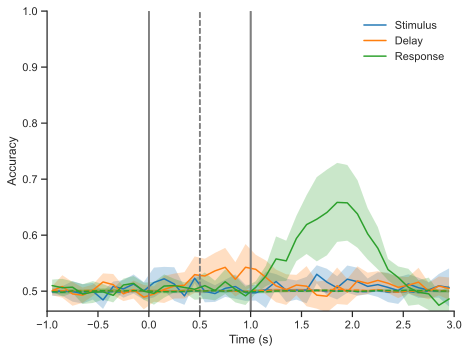

In [10]:
%%time
# Run mean epoch cross decoder across sessions
# results_stim = mean_decoder(kind='epoch_ortho', epoch='stim', epoch_ortho='delay', engagement=1, save=False)
# results_delay = mean_decoder(kind='epoch_ortho', epoch='delay', epoch_ortho='stim', engagement=1, save=False)
# results_resp = mean_decoder(kind='epoch_ortho', epoch='resp', epoch_ortho='delay', engagement=1, save=False)

# Load mean epoch cross decoder results across sessions
# with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_stim_engaged.pkl'), 'rb') as f:
#     results_stim = pickle.load(f)
# with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_delay_engaged.pkl'), 'rb') as f:
#     results_delay = pickle.load(f)
# with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_resp_engaged.pkl'), 'rb') as f:
#     results_resp = pickle.load(f)

# Plot mean epoch cross decoder results across sessions
plt.figure(constrained_layout=True)
plot_mean_epoch_cross_decoder(results_stim, epoch='stim', errorbar='ci', z_null=False)
plot_mean_epoch_cross_decoder(results_delay, epoch='delay', errorbar='ci', z_null=False)
plot_mean_epoch_cross_decoder(results_resp, epoch='resp', errorbar='ci', z_null=False)
n_sessions = len(results_stim['acc'])
n_trials = np.sum([results_stim['acc'][i].shape[0] for i in range(len(results_stim['acc']))])
plt.title(f'Decoding accuracy\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

# Splits

In [51]:
def plot_mean_decoder_subjects_split(subjects, folder_parent, compute=False, what='stim', kind='epoch_split', epoch='stim', split_by='Hit', engagement=None, n_shuffles=100, save=False):

    figsize = fig_size(n_cols=2, ratio=1)

    keys = ['acc', 'acc_null', 'pred', 'pred_err']
    mean_results = {k: [] for k in keys}

    if split_by == 'Hit':
        filename = f'{what}_epoch_split_decoder_{epoch}_split_by_{split_by}_engaged_(stim aligned).pkl'
        split = 'hit'
        if kind == 'generalize':
            filename = f'{what}_epoch_{kind}_decoder_{epoch}_{kind}_{split_by}_engaged_(stim aligned).pkl'
    elif split_by == 'Engaged':
        # filename = f'{what}_epoch_split_decoder_{epoch}_split_by_{split_by}_hit_only_(stim aligned).pkl'
        filename = f'{what}_epoch_generalize_decoder_{epoch}_generalize_{split_by}_hit_only_(stim aligned).pkl'
        split = 'engagement'
    print(filename)

    for subj in subjects:

        if compute:  # Run mean epoch cross decoder split across sessions
            results = mean_decoder(subj, what=what, kind=kind, epoch=epoch, split_by=split_by, engagement=engagement, n_shuffles=n_shuffles, save=save)
        else:  # Load mean within decoder results across sessions
            path = Path(folder_parent / subj / filename)
            with open(path, 'rb') as f:
                results = pickle.load(f)

        for k in keys:
            mean_results[k].extend(results.get(k, []))
            mean_results['bins'] = results['bins']

        # # Plot mean epoch cross decoder split results across sessions
        # plt.figure(constrained_layout=True, figsize=figsize)
        # plot_mean_epoch_cross_decoder_split(results, errorbar='ci', z_null=True)
        # n_sessions = len(results['acc'])
        # n_trials = np.sum([results['acc'][i][0].shape[0] for i in range(len(results['acc']))])
        # plt.title(f'Stimulus code\n'
        #           f'{subj}, {n_sessions} sessions, {n_trials} trials')

    # Plot mean within decoder results across mice
    plt.figure(constrained_layout=True, figsize=figsize)
    plot_mean_epoch_cross_decoder_split(mean_results, what=what, epoch=epoch, split=split, errorbar='ci', z_null=False)
    n_sessions = len(mean_results['acc'])
    n_trials = np.sum([mean_results['acc'][i][0].shape[0] for i in range(len(mean_results['acc']))])
    # plt.title(f'Decoding accuracy ({epoch} epoch)\n'
    #           f'{len(subjects)} mice, {n_sessions} sessions, {n_trials} trials')

## By Outcome

### Train in all trials and test split by outcome
Epoch cross temporal decoder split


#### Stimulus code

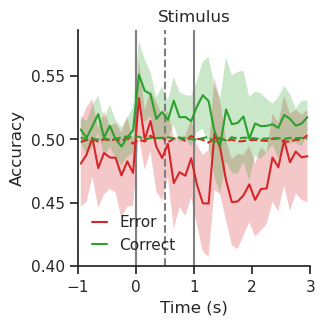

In [65]:
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=False, what='stim', epoch='stim', split_by='Hit', engagement=1, n_shuffles=100, save=True)
plt.title('Stimulus')
# plt.gca().get_legend().remove()
plt.ylim(0.4, None)
plt.legend(loc='lower right')
plt.legend(handlelength=1)  # Default is 2

Note the different mean null accuracy for both splits. This is correct.

Accuracy remains relatively stable around chance (~0.5) before stimulus onset (0s). A transient increase in decoding accuracy around 0s in correct trials, but no strong sustained difference between error and correct trials.
After ~1s, accuracy for correct trials trends slightly higher than for errors, but the separation is modest. For error trials the shuffles closely follow the downward trend of the code because in every error trial the animal licked to the opposite side of stimulus (what I am decoding).
What is more weird is that there's also a lot of code in correct trials's shuffles. It could be a bias.

In errors the stimulus is well represented, but the mouse prepare (delay) and execute (response) the wrong choice.

#### Delay code

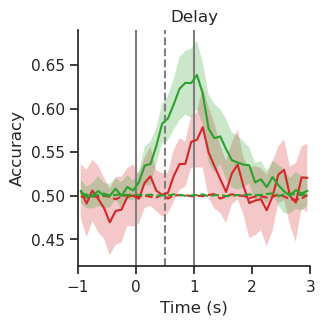

In [49]:
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=False, what='stim', epoch='delay', split_by='Hit', engagement=1, n_shuffles=100, save=True)
plt.title('Delay')
plt.gca().get_legend().remove()

#### Response code

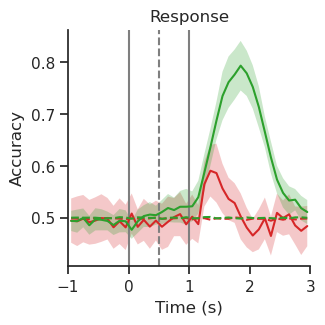

In [50]:
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=False, what='stim', epoch='resp', split_by='Hit', engagement=1, n_shuffles=100, save=True)
plt.title('Response')
plt.gca().get_legend().remove()

Larger accuracy in correct trials because there is reward and therefore more licks.

### Train in correct and test in errors
Cross-validate in correct, generalize in errors. Engaged trials only\
Epoch cross temporal generalization decoder

#### Stimulus code

stim_epoch_generalize_decoder_stim_generalize_Hit_engaged_(stim aligned).pkl
choice_epoch_generalize_decoder_stim_generalize_Hit_engaged_(stim aligned).pkl


Text(0.5, 1.0, 'Stimulus\n(decode choice)')

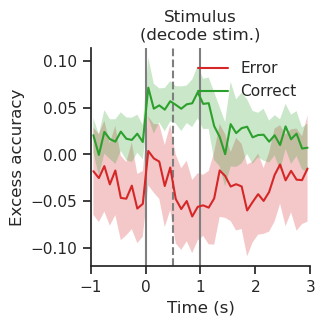

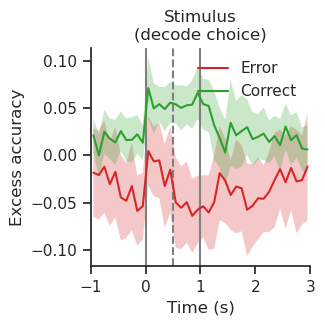

In [112]:
# Decode stimulus
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=False, what='stim', kind='generalize', epoch='stim', split_by='Hit', engagement=1, n_shuffles=100, save=True)
plt.title('Stimulus\n(decode stim.)')

# Decode choice
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=False, what='choice', kind='generalize', epoch='stim', split_by='Hit', engagement=1, n_shuffles=100, save=True)
plt.title('Stimulus\n(decode choice)')

#### Delay code

stim_epoch_generalize_decoder_delay_generalize_Hit_engaged_(stim aligned).pkl
choice_epoch_generalize_decoder_delay_generalize_Hit_engaged_(stim aligned).pkl


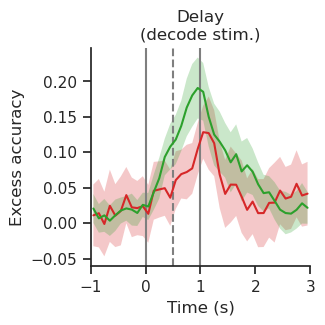

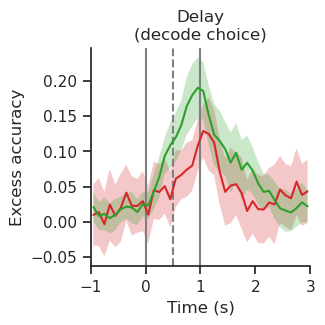

In [95]:
# Decode stimulus
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=False, what='stim', kind='generalize', epoch='delay', split_by='Hit', engagement=1, n_shuffles=100, save=True)
plt.title('Delay\n(decode stim.)')
plt.gca().get_legend().remove()

# Decode choice
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=False, what='choice', kind='generalize', epoch='delay', split_by='Hit', engagement=1, n_shuffles=100, save=True)
plt.title('Delay\n(decode choice)')
plt.gca().get_legend().remove()

#### Response code

stim_epoch_generalize_decoder_resp_generalize_Hit_engaged_(stim aligned).pkl
choice_epoch_generalize_decoder_resp_generalize_Hit_engaged_(stim aligned).pkl


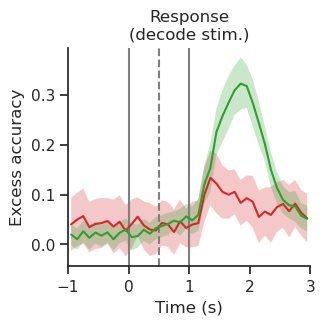

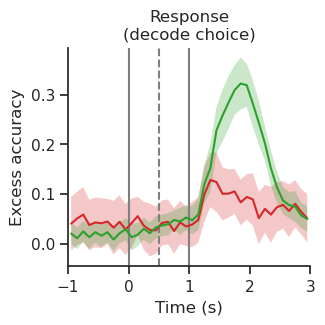

In [96]:
# Decode stimulus
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=False, what='stim', kind='generalize', epoch='resp', split_by='Hit', engagement=1, n_shuffles=100, save=True)
plt.title('Response\n(decode stim.)')
plt.gca().get_legend().remove()

# Decode choice
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=False, what='choice', kind='generalize', epoch='resp', split_by='Hit', engagement=1, n_shuffles=100, save=True)
plt.title('Response\n(decode choice)')
plt.gca().get_legend().remove()

## By Engagement
Testing comparison of decoding accuracy of epoch cross decoder between engagement states (engaged vs disengaged)

### Train in all trials and test split by state
Epoch cross temporal decoder split

#### Stimulus

Text(0.5, 1.0, 'Stimulus')

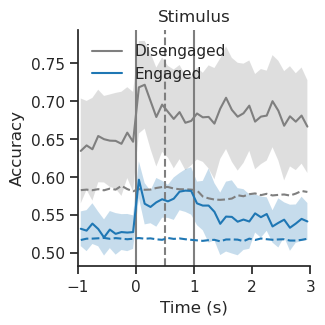

In [31]:
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=False, what='stim', epoch='stim', split_by='Engaged', engagement=None, n_shuffles=100, save=True)
plt.title('Stimulus')

#### Delay

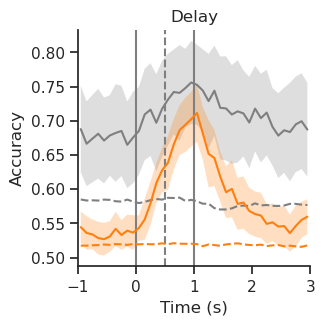

In [55]:
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=False, what='stim', epoch='delay', split_by='Engaged', engagement=None, n_shuffles=100, save=True)
plt.title('Delay')
plt.gca().get_legend().remove()

#### Response

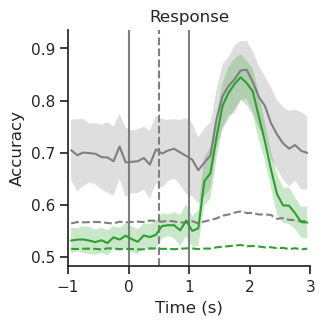

In [56]:
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=False, what='stim', epoch='resp', split_by='Engaged', engagement=None, n_shuffles=100, save=True)
plt.title('Response')
plt.gca().get_legend().remove()

### Train in engaged and test in disengaged
Cross-validate in engaged, generalize in disengaged. Correct trials only\
Epoch cross temporal generalization decoder

#### Stimulus

stim_epoch_generalize_decoder_stim_generalize_Engaged_hit_only_(stim aligned).pkl
choice_epoch_generalize_decoder_stim_generalize_Engaged_hit_only_(stim aligned).pkl


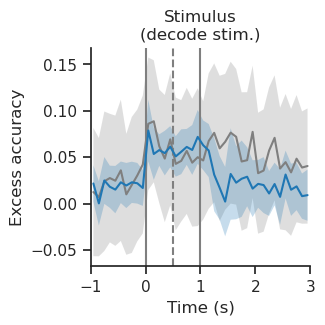

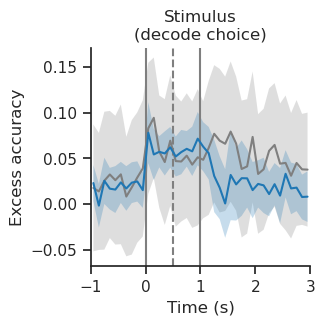

In [98]:
# Decode stimulus
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=False, what='stim', epoch='stim', split_by='Engaged', engagement=None, n_shuffles=100, save=False)
plt.title('Stimulus\n(decode stim.)')
plt.gca().get_legend().remove()

# Decode choice
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=False, what='choice', epoch='stim', split_by='Engaged', engagement=None, n_shuffles=100, save=False)
plt.title('Stimulus\n(decode choice)')
plt.gca().get_legend().remove()

#### Delay

stim_epoch_generalize_decoder_delay_generalize_Engaged_hit_only_(stim aligned).pkl
choice_epoch_generalize_decoder_delay_generalize_Engaged_hit_only_(stim aligned).pkl


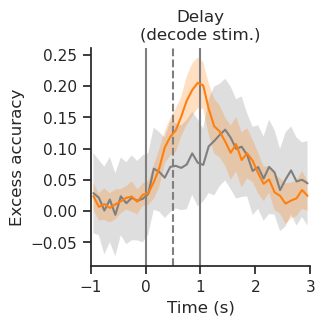

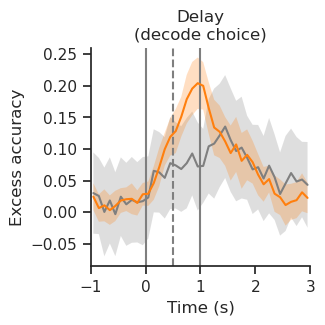

In [99]:
# Decode stimulus
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=False, what='stim', epoch='delay', split_by='Engaged', engagement=None, n_shuffles=100, save=False)
plt.title('Delay\n(decode stim.)')
plt.gca().get_legend().remove()

# Decode choice
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=False, what='choice', epoch='delay', split_by='Engaged', engagement=None, n_shuffles=100, save=False)
plt.title('Delay\n(decode choice)')
plt.gca().get_legend().remove()

#### Response

stim_epoch_generalize_decoder_resp_generalize_Engaged_hit_only_(stim aligned).pkl
choice_epoch_generalize_decoder_resp_generalize_Engaged_hit_only_(stim aligned).pkl


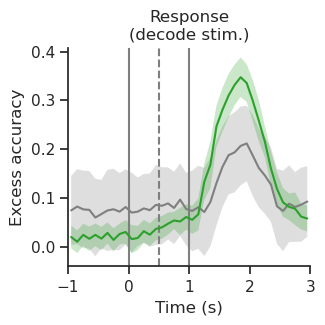

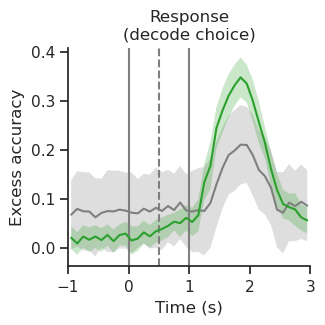

In [100]:
# Decode stimulus
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=False, what='stim', epoch='resp', split_by='Engaged', engagement=None, n_shuffles=100, save=False)
plt.title('Response\n(decode stim.)')
plt.gca().get_legend().remove()

# Decode choice
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=False, what='choice', epoch='resp', split_by='Engaged', engagement=None, n_shuffles=100, save=False)
plt.title('Response\n(decode choice)')
plt.gca().get_legend().remove()

# Population selectivity analysis

From:
Inagaki, H. K., Chen, S., Ridder, M. C., Sah, P., Li, N., Yang, Z., Hasanbegovic, H., Gao, Z., Gerfen, C. R., & Svoboda, K. (2022). A midbrain-thalamus-cortex circuit reorganizes cortical dynamics to initiate movement. Cell, 185(6), 1065-1081.e23. https://doi.org/10.1016/j.cell.2022.02.006

In [17]:
# Align to stimulus onset
df_behavior = behavior[0]
bins = np.load(folder_parent / ephys_ids[0] / 'bins.npy')
all_psth = np.load(folder_parent / ephys_ids[0] / 'all_psth.npy')

# Step 1: Separate trials by condition
left_lick_trials = df_behavior[df_behavior.Choice == 0].Trial
right_lick_trials = df_behavior[df_behavior.Choice == 1].Trial

# Step 2: Compute mean firing rates per time bin
r_lick_left = np.mean(all_psth[left_lick_trials], axis=0)  # shape (bins, neurons)
r_lick_right = np.mean(all_psth[right_lick_trials], axis=0)  # shape (bins, neurons)

# Step 3: Compute selectivity vector w_t
wt = r_lick_right - r_lick_left  # shape (bins, neurons)

# Step 4: Perform SVD to get the dominant coding direction
U, S, Vt = np.linalg.svd(wt, full_matrices=False)

# Step 5: CD_delay is the first right singular vector (principal axis)
CD_delay = Vt[0, :]  # First singular vector (neurons,)

# Step 6: Normalize to unit vector
CD_delay /= np.linalg.norm(CD_delay)

# Step 7: Compute correlation matrix
corr_matrix = np.corrcoef(wt)
# np.fill_diagonal(corr_matrix, np.nan)  # Remove diagonal by setting it to NaN

# Step 8: Plot correlation matrix
plt.figure(constrained_layout=True)
plt.imshow(corr_matrix, cmap='coolwarm', origin='lower')
plt.axhline(np.where(bins == 0)[0], color='k', linestyle='-')  # Stimulus onset
plt.axvline(np.where(bins == 0)[0], color='k', linestyle='-')  # Stimulus onset
plt.axhline(np.where(bins == 0.5)[0], color='k', linestyle='-')  # Delay
plt.axvline(np.where(bins == 0.5)[0], color='k', linestyle='-')  # Delay
plt.axhline(np.where(bins == 1)[0], color='k', linestyle='-')  # Go cue
plt.axvline(np.where(bins == 1)[0], color='k', linestyle='-')  # Go cue
plt.xticks(np.arange(0, len(bins), 10), np.round(bins[::10]).astype(int))
plt.yticks(np.arange(0, len(bins), 10), np.round(bins[::10]).astype(int))
plt.colorbar(label="Pearson's correlation\nof selectivity vector")
plt.xlabel('Time from stim. onset (s)')
plt.ylabel('Time from stim. onset (s)')
# plt.title('Correlation of Population Selectivity Over Time')
sns.despine()

NameError: name 'behavior' is not defined

Pearson's correlation is high during the delay epoch (0.5-1 s), meaning that a similar subpopulation of neurons holds selectivity during motor planning. In contrast, population selectivity show a low correlation before and after the Go cue (1 s), meaning that different subpopulations of neurons show selectivity. Population activity patterns in M2 change rapidly before and during movement initiation.

In [ ]:
# Compute the total number of trials in behavior
total_trials = sum([df.shape[0] for df in behavior])
print('Total trials:', total_trials)

# Compute the total number of trials in behavior that were misses
total_missed = sum([df[df.Miss == 1].shape[0] for df in behavior])
print('Total missed:', total_missed)

# Compute the total number of trials in behavior that were responses
total_responded = sum([df[df.Response == 1].shape[0] for df in behavior])
print('Total responded:', total_responded)

# Check if the total number of trials equals the sum of missed and responded trials
assert (total_trials == total_missed + total_responded), \
    f"Total trials {total_trials} do not equal to missed trials {total_missed} + response trials {total_responded}"

In [ ]:
import ast

# Merge all behavior dataframes in a single one
df_behavior_all = pd.concat(behavior, ignore_index=True)

# Keep nly engaged trials
df_behavior_all = df_behavior_all[df_behavior_all.Engaged == 1].reset_index(drop=True)

# Convert Port1In and Port2In columns to lists of floats (from list of strings)
df_behavior_all["Port1In"] = df_behavior_all["Port1In"].apply(lambda x: ast.literal_eval(x.strip()))
df_behavior_all["Port2In"] = df_behavior_all["Port2In"].apply(lambda x: ast.literal_eval(x.strip()))

In [ ]:
peri_stim_licks = get_peri_stim_licks(df_behavior_all)
bins, licks_psth = compute_psth(peri_stim_licks)
fig, ax = plt.subplots()
plot_psth_split(condition='outcome', over='licks', ax=ax)

# Remove top and right spines
sns.despine()

# Add legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, frameon=False)
n_sessions = len(results_resp['acc'])
n_trials = np.sum([results_resp['acc'][i][0].shape[0] for i in range(len(results_resp['acc']))])
plt.title(f'Lick PSTH\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

# Save all notebook's figures

In [78]:
# # Whole notebook ouputs (no input or prompt, only Markdown and figures)
# # As HTML
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt
# # As PDF
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt
#
# Export all figures
save_notebook_files('notebook.ipynb')

Saved 11 images to notebook_files/
